<a href="https://colab.research.google.com/github/fartech00/Prompt-refining/blob/main/TAFU_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ================================
# 1: Kutibxonalarni chaqirib olamiz
# ================================
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns


Malumot shakli: (1797, 64)
Belgilanganlar: (1797,)


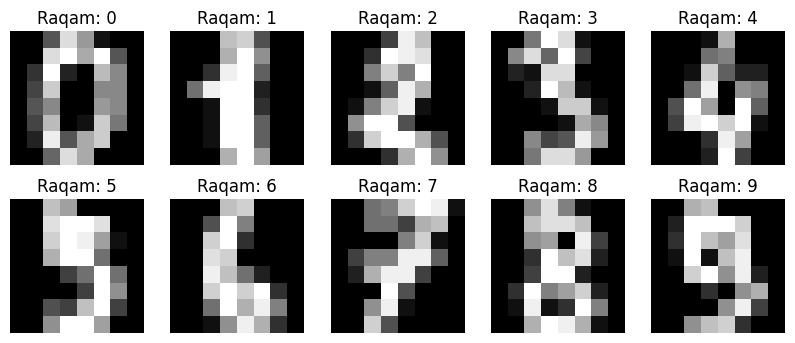

In [24]:
# ================================
# 2: Rasmli malumotlarni yuklab olamiz
# ================================
digits = datasets.load_digits()
X = digits.data    # 8x8=64, yani har bir rasmni son ko'rinishida ibodalab olamiz
y = digits.target  # va bu sonlar qaysi raqamni DNK si ekanini bilgilab olamiz

print("Malumot shakli:", X.shape)
print("Belgilanganlar:", y.shape)

# Rasmli malumotlarni ifodalash uchun code
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Raqam: {digits.target[i]}")
    plt.axis('off')
plt.show()


In [25]:
# ================================
# 3: Train/Test ga ajratib olamiz
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# RAqamlarni xususiyatlarini qiymatlab olamiz
# agarda biz insonni tashqi ko'rinishini klassifikatsiya qilayotgan bo'lsak:
    # Bo'yi: 150-200
    # Vazni: 50-120
    # deb belgilasak. Bunda algoritm Insonni bo'yi muhimroq, chunki qiymati kattaroq deb hisoblab qolishi mumkin.
# Shuning uchun raqamlarni xususiyatlarini qiymatlab olamiz.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)   #  k=5
knn.fit(X_train, y_train)                   # Train on training data
print("✅ K-NN Modeli o'rganishni tugatdi.")



✅ K-NN Modeli o'rganishni tugatdi.


ANIQLILIGI: 0.9703703703703703

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      1.00      0.97        55
           2       0.96      1.00      0.98        53
           3       0.98      0.98      0.98        55
           4       0.98      0.93      0.95        54
           5       0.98      0.96      0.97        55
           6       0.98      0.98      0.98        54
           7       0.93      0.98      0.95        54
           8       0.98      0.92      0.95        52
           9       0.96      0.94      0.95        54

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



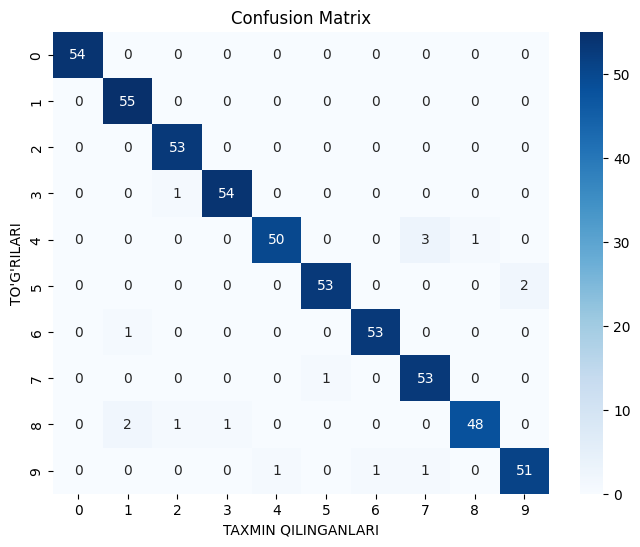

In [26]:
# TEST QILISH
# ================================
y_pred = knn.predict(X_test)

print("ANIQLILIGI:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.xlabel("TAXMIN QILINGANLARI")
plt.ylabel("TO'G'RILARI")
plt.title("Confusion Matrix")
plt.show()


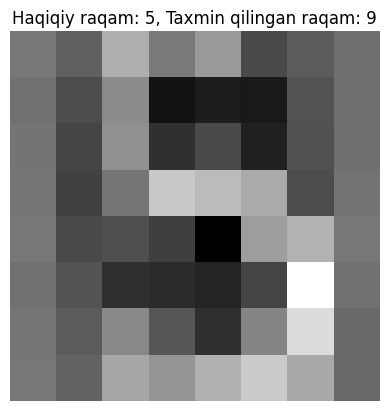

In [29]:
# 4: K-NN da turli raqamlarni klassifikatsiya qilish testi
# ================================
import numpy as np
rand_index = np.random.randint(0, len(X_test))

# Test qilinayotgan raqamni ifodalash
plt.imshow(X_test[rand_index].reshape(8, 8), cmap='gray')
plt.title(f"Haqiqiy raqam: {y_test[rand_index]}, Taxmin qilingan raqam: {knn.predict([X_test[rand_index]])[0]}")
plt.axis('off')
plt.show()